In [1]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

# 1. Asegurar el path del proyecto
sys.path.insert(0, '.')

# 2. Definición ROBUSTA de la ruta (Pathlib autodetecta el separador / o \)
# Usamos .resolve() para estar seguros de la ubicación absoluta si es necesario
DATA_RAW_DIR = Path("data") / "raw"

files = {
    'application_train': 'application_train.csv',
    'application_test':  'application_test.csv',  
    'bureau':            'bureau.csv',
    'bureau_balance':    'bureau_balance.csv',
    'previous_application': 'previous_application.csv',
    'POS_CASH_balance':  'POS_CASH_balance.csv',
    'credit_card_balance': 'credit_card_balance.csv',
    'installments_payments': 'installments_payments.csv',
}

2. Script de Inspección de Datos

In [2]:

# 3. Bucle de inspección corregido
for name, filename in files.items():
    # Combinamos la ruta de forma limpia
    path = DATA_RAW_DIR / filename
    
    if not path.exists():
        # Intentamos buscarlo un nivel arriba si el notebook está en /notebooks
        alternative_path = Path("..") / "data" / "raw" / filename
        if alternative_path.exists():
            path = alternative_path
        else:
            print(f"⚠️ Archivo no encontrado: {path} (ni en ..)")
            continue
        
    df = pd.read_csv(path)
    print(f"{'='*20} {name} {'='*20}")
    print(f"Lignes: {len(df)} | Colonnes: {len(df.columns)}\n")
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_null = df[col].isna().sum()
        pct_null = round(n_null / len(df) * 100, 1)
        
        if dtype in ['object', 'string']:
            uniq = df[col].nunique()
            sample = str(list(df[col].dropna().unique()[:4]))
            print(f"  {col:<40} | {dtype:<7} | null: {pct_null:>5}% | card: {uniq:<9} | ex: {sample}")
        else:
            if np.issubdtype(df[col].dtype, np.number) and n_null < len(df):
                mn = round(float(df[col].min()), 2)
                mx = round(float(df[col].max()), 2)
            else:
                mn, mx = 'N/A', 'N/A'
            print(f"  {col:<40} | {dtype:<7} | null: {pct_null:>5}% | min: {mn:<10} | max: {mx}")
    print("\n")

==================== application_train ====================
Lignes: 307511 | Colonnes: 122

  SK_ID_CURR                               | int64   | null:   0.0% | min: 100002.0   | max: 456255.0
  TARGET                                   | int64   | null:   0.0% | min: 0.0        | max: 1.0
  NAME_CONTRACT_TYPE                       | object  | null:   0.0% | card: 2         | ex: ['Cash loans', 'Revolving loans']
  CODE_GENDER                              | object  | null:   0.0% | card: 3         | ex: ['M', 'F', 'XNA']
  FLAG_OWN_CAR                             | object  | null:   0.0% | card: 2         | ex: ['N', 'Y']
  FLAG_OWN_REALTY                          | object  | null:   0.0% | card: 2         | ex: ['Y', 'N']
  CNT_CHILDREN                             | int64   | null:   0.0% | min: 0.0        | max: 19.0
  AMT_INCOME_TOTAL                         | float64 | null:   0.0% | min: 25650.0    | max: 117000000.0
  AMT_CREDIT                               | float64 | null:   0

In [5]:
path = Path("..") / "data" / "raw" / "application_train.csv"
app_train = pd.read_csv(path)
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
path = Path("..") / "data" / "raw" / "application_test.csv"
app_test = pd.read_csv(path)
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


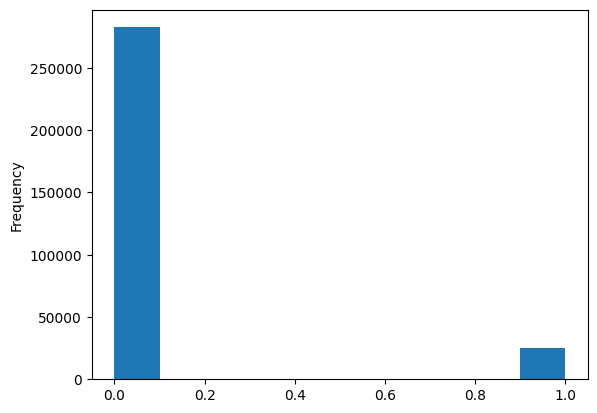

In [7]:
app_train['TARGET'].astype(int).plot.hist();

In [8]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [9]:
# Missing values statistics
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


In [10]:
# Number of each type of column
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [11]:
# Number of unique classes in each object column
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64